# Merkle-Hellman subset-sum demo

Small, reproducible walk-through for the toy cryptanalysis pipeline.

In [8]:
from pathlib import Path
import json
import sys

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

src_path = PROJECT_ROOT / "src"
if src_path.exists() and str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from annealing_crypto.experiments.run_benchmark import benchmark_config_from_mapping
from annealing_crypto.experiments.summarize_results import summarize_benchmark
from annealing_crypto.experiments.validate_results import validate_benchmark_csv
from annealing_crypto.metrics import hamming_distance
from annealing_crypto.merkle_hellman import decrypt_ciphertext, encrypt_bits, generate_keypair
from annealing_crypto.qubo import build_subset_sum_bqm
from annealing_crypto.solvers import (
    solve_brute_force,
    solve_exact_qubo,
    solve_simulated_annealing,
    solve_simulated_quantum_annealing,
)
from annealing_crypto.subset_sum import instance_from_merkle_hellman, objective_value

config_path = PROJECT_ROOT / "experiments/configs/report_benchmark.json"
benchmark_path = PROJECT_ROOT / "experiments/raw/benchmark.csv"
summary_path = PROJECT_ROOT / "experiments/processed/summary.csv"
plots_dir = PROJECT_ROOT / "experiments/plots"

pd.set_option("display.max_columns", 30)

## Reproducible experiment setup

The benchmark used for the report is described by a versioned JSON config. The generated CSV and plots are intentionally kept local, but the parameters below should make the run reproducible.

In [9]:
benchmark_config = benchmark_config_from_mapping(json.loads(config_path.read_text()))
pd.DataFrame(
    {
        "parameter": benchmark_config.__dict__.keys(),
        "value": [repr(value) for value in benchmark_config.__dict__.values()],
    }
)

,parameter,value
0,sizes,"(8, 12, 16)"
1,trials,5
2,base_seed,20260504
3,sources,"('random', 'merkle_hellman')"
4,solvers,"('brute_force', 'simulated_annealing', 'simula..."
5,brute_force_max_bits,24
6,exact_qubo_max_bits,18
7,annealing_reads,100
8,annealing_sweeps,500
9,quantum_reads,20


## Toy ciphertext

In [10]:
keypair = generate_keypair(8, seed=42)
message = (1, 0, 1, 1, 0, 0, 1, 0)
ciphertext = encrypt_bits(keypair.public, message)
instance = instance_from_merkle_hellman(keypair.public, ciphertext, known_message=message)

{
    "public_weights": keypair.public.weights,
    "message": message,
    "ciphertext": ciphertext,
    "legal_decryption": decrypt_ciphertext(keypair.private, ciphertext),
}

{'public_weights': (5008, 2536, 405, 3410, 1940, 1259, 2923, 5787),
 'message': (1, 0, 1, 1, 0, 0, 1, 0),
 'ciphertext': 11746,
 'legal_decryption': (1, 0, 1, 1, 0, 0, 1, 0)}

## Solvers

In [11]:
results = [
    solve_brute_force(instance),
    solve_exact_qubo(instance),
    solve_simulated_annealing(instance, num_reads=100, num_sweeps=500, seed=42),
    solve_simulated_quantum_annealing(
        instance,
        num_reads=20,
        num_sweeps=80,
        trotter_slices=4,
        seed=42,
    ),
]

pd.DataFrame(
    {
        "solver": result.solver,
        "solution": result.solution,
        "objective_value": objective_value(instance, result.solution),
        "exact_hit": result.exact_hit,
        "matches_message": result.solution == message,
        "hamming_distance": hamming_distance(result.solution, message),
        "runtime_ms": result.runtime_ms,
    }
    for result in results
)

,solver,solution,objective_value,exact_hit,matches_message,hamming_distance,runtime_ms
0,brute_force,"(1, 0, 1, 1, 0, 0, 1, 0)",0,True,True,0,0.230667
1,exact_qubo,"(1, 0, 1, 1, 0, 0, 1, 0)",0,True,True,0,0.653583
2,simulated_annealing,"(1, 0, 1, 1, 0, 0, 1, 0)",0,True,True,0,5.127833
3,simulated_quantum_annealing,"(1, 0, 1, 1, 0, 0, 1, 0)",0,True,True,0,93.634584


## QUBO energy

In [12]:
bqm = build_subset_sum_bqm(instance)
{
    "variables": len(bqm.variables),
    "quadratic_terms": len(bqm.quadratic),
    "energy_for_message": bqm.energy(dict(enumerate(message))),
}

{'variables': 8, 'quadratic_terms': 28, 'energy_for_message': np.float64(0.0)}

## Benchmark CSV

`exact_hit_rate` means the solver found a subset with objective value 0. `known_solution_match_rate` is stricter: it checks whether the recovered bits match the planted message/vector.

In [13]:
if benchmark_path.exists():
    validation_report = validate_benchmark_csv(benchmark_path, config=benchmark_config)
    display(validation_report.as_dict())
    benchmark = pd.read_csv(benchmark_path)
    display(benchmark.head())
    if summary_path.exists():
        display(pd.read_csv(summary_path))
    else:
        display(summarize_benchmark(benchmark_path))
else:
    print("Run annealing-crypto-benchmark first to create experiments/raw/benchmark.csv")

{'ok': True,
 'rows': 90,
 'checks': ['required columns present',
  'exact-hit flags match objective values',
  'hamming distances and planted-vector flags are consistent',
  'runtime values are non-negative',
  'row count and benchmark grid match config']}

,scenario_id,source,n_bits,trial,seed,solver,success,exact_hit,known_solution_match,objective_value,runtime_ms,hamming_distance,target,weight_sum,evaluated_states,num_reads,num_sweeps,trotter_slices,beta,transverse_field_start,transverse_field_end
0,random-n8-t0-s20268504,random,8,0,20268504,brute_force,True,True,True,0.0,0.221875,0,2463639,2791052,174.0,NaN,NaN,NaN,NaN,NaN,NaN
1,random-n8-t0-s20268504,random,8,0,20268504,simulated_annealing,True,True,True,0.0,8.071959,0,2463639,2791052,NaN,100.0,500.0,NaN,NaN,NaN,NaN
2,random-n8-t0-s20268504,random,8,0,20268504,simulated_quantum_annealing,True,True,True,0.0,178.528458,0,2463639,2791052,NaN,20.0,100.0,6.0,0.05,2.0,0.02
3,random-n8-t1-s20268505,random,8,1,20268505,brute_force,True,True,True,0.0,0.184875,0,818653,2909441,153.0,NaN,NaN,NaN,NaN,NaN,NaN
4,random-n8-t1-s20268505,random,8,1,20268505,simulated_annealing,True,True,True,0.0,5.028750,0,818653,2909441,NaN,100.0,500.0,NaN,NaN,NaN,NaN


,source,solver,n_bits,trials,exact_hit_rate,known_solution_match_rate,mean_runtime_ms,median_runtime_ms,median_objective_value,mean_hamming_distance
0,merkle_hellman,brute_force,8,5,1.0,1.0,0.173183,0.169792,0.0,0.0
1,merkle_hellman,brute_force,12,5,1.0,1.0,2.368692,1.838541,0.0,0.0
2,merkle_hellman,brute_force,16,5,1.0,1.0,55.497275,55.134292,0.0,0.0
3,merkle_hellman,simulated_annealing,8,5,1.0,1.0,4.758542,4.846750,0.0,0.0
4,merkle_hellman,simulated_annealing,12,5,0.4,0.4,7.193075,7.741917,400.0,3.4
5,merkle_hellman,simulated_annealing,16,5,0.2,0.2,10.558675,10.330084,10080625.0,6.4
6,merkle_hellman,simulated_quantum_annealing,8,5,1.0,1.0,173.932133,174.476500,0.0,0.0
7,merkle_hellman,simulated_quantum_annealing,12,5,0.4,0.4,308.535408,307.387833,400.0,2.2
8,merkle_hellman,simulated_quantum_annealing,16,5,0.0,0.0,464.694167,465.780667,3701776.0,9.4
9,random,brute_force,8,5,1.0,1.0,0.165067,0.184875,0.0,0.0


### Short interpretation

- `Brute force` is the correctness baseline: it should hit exact solutions for these small instances, but its cost grows exponentially.
- `Simulated annealing` and the local `simulated quantum annealing` solver are heuristics. Their hit rate drops as the Merkle-Hellman-derived instances grow.
- The SQA solver here is a local simulation with Trotter replicas, not a physical QPU run. Its runtime is therefore CPU/Python overhead plus the simulated annealing schedule.
- `exact_hit_rate` is the main subset-sum success metric. `known_solution_match_rate` is stricter and matters when interpreting recovery of the planted message bits.

## Generated plots

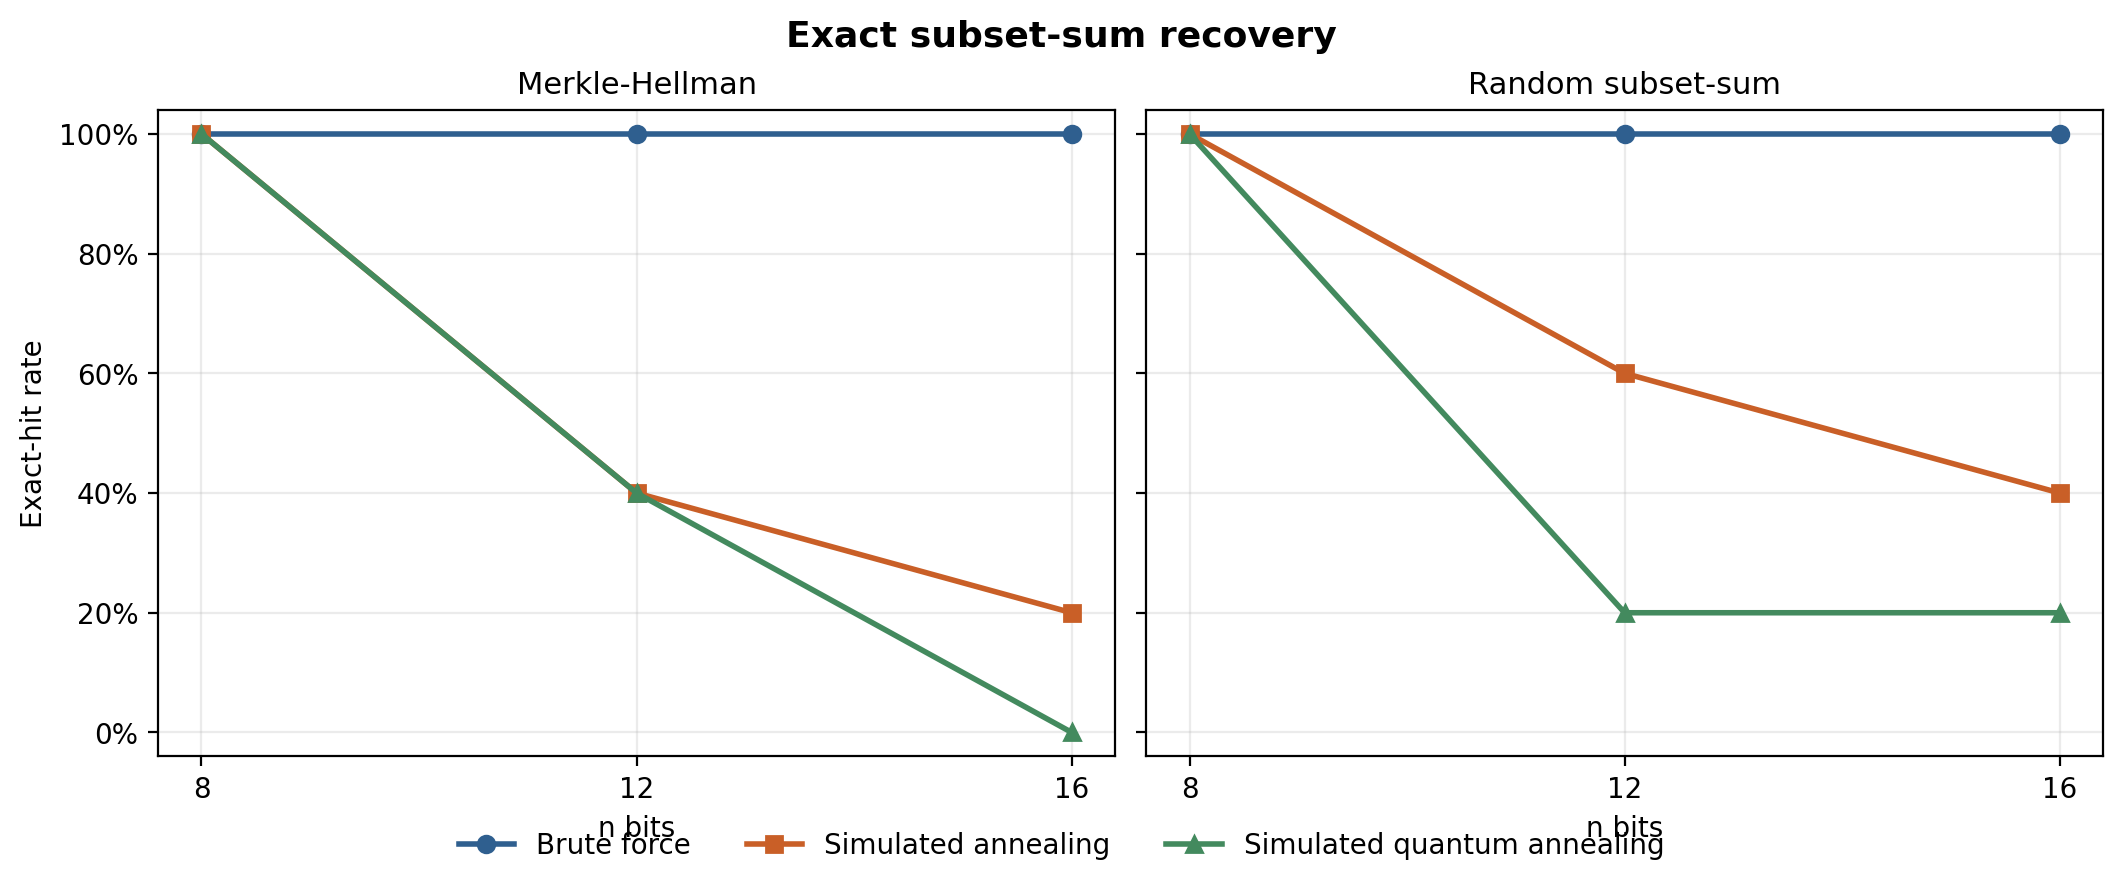

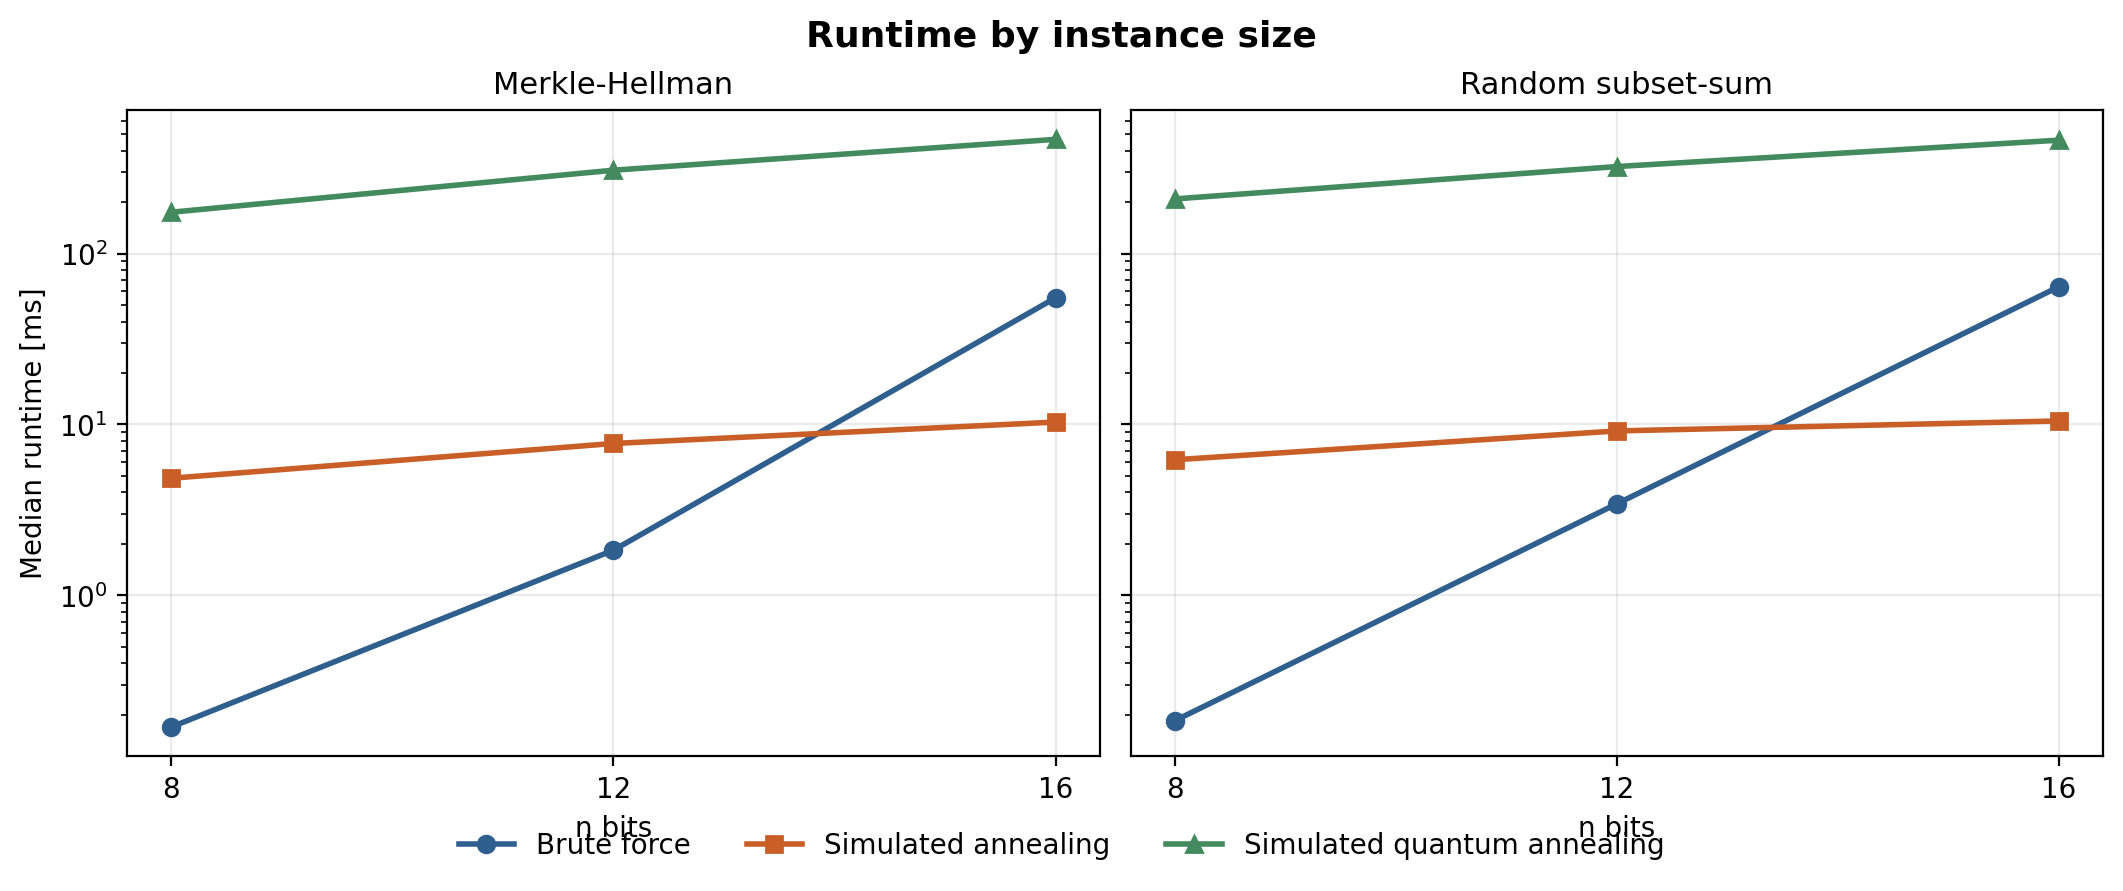

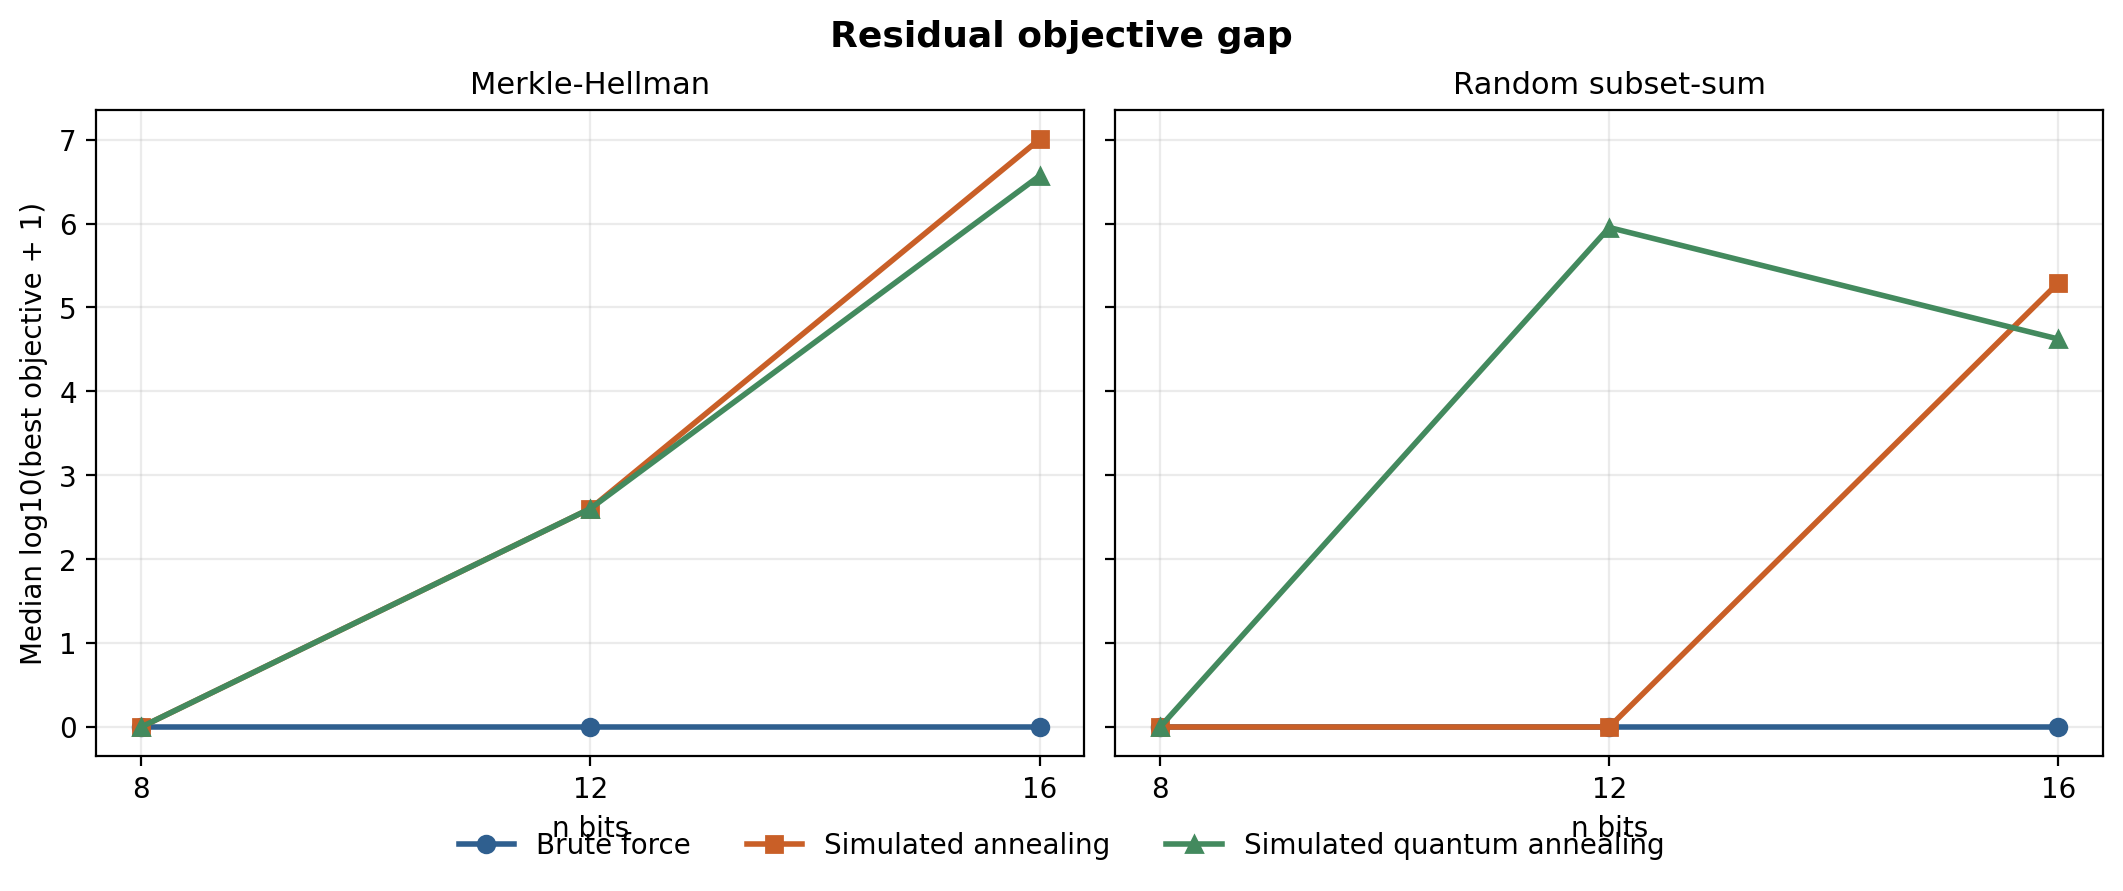

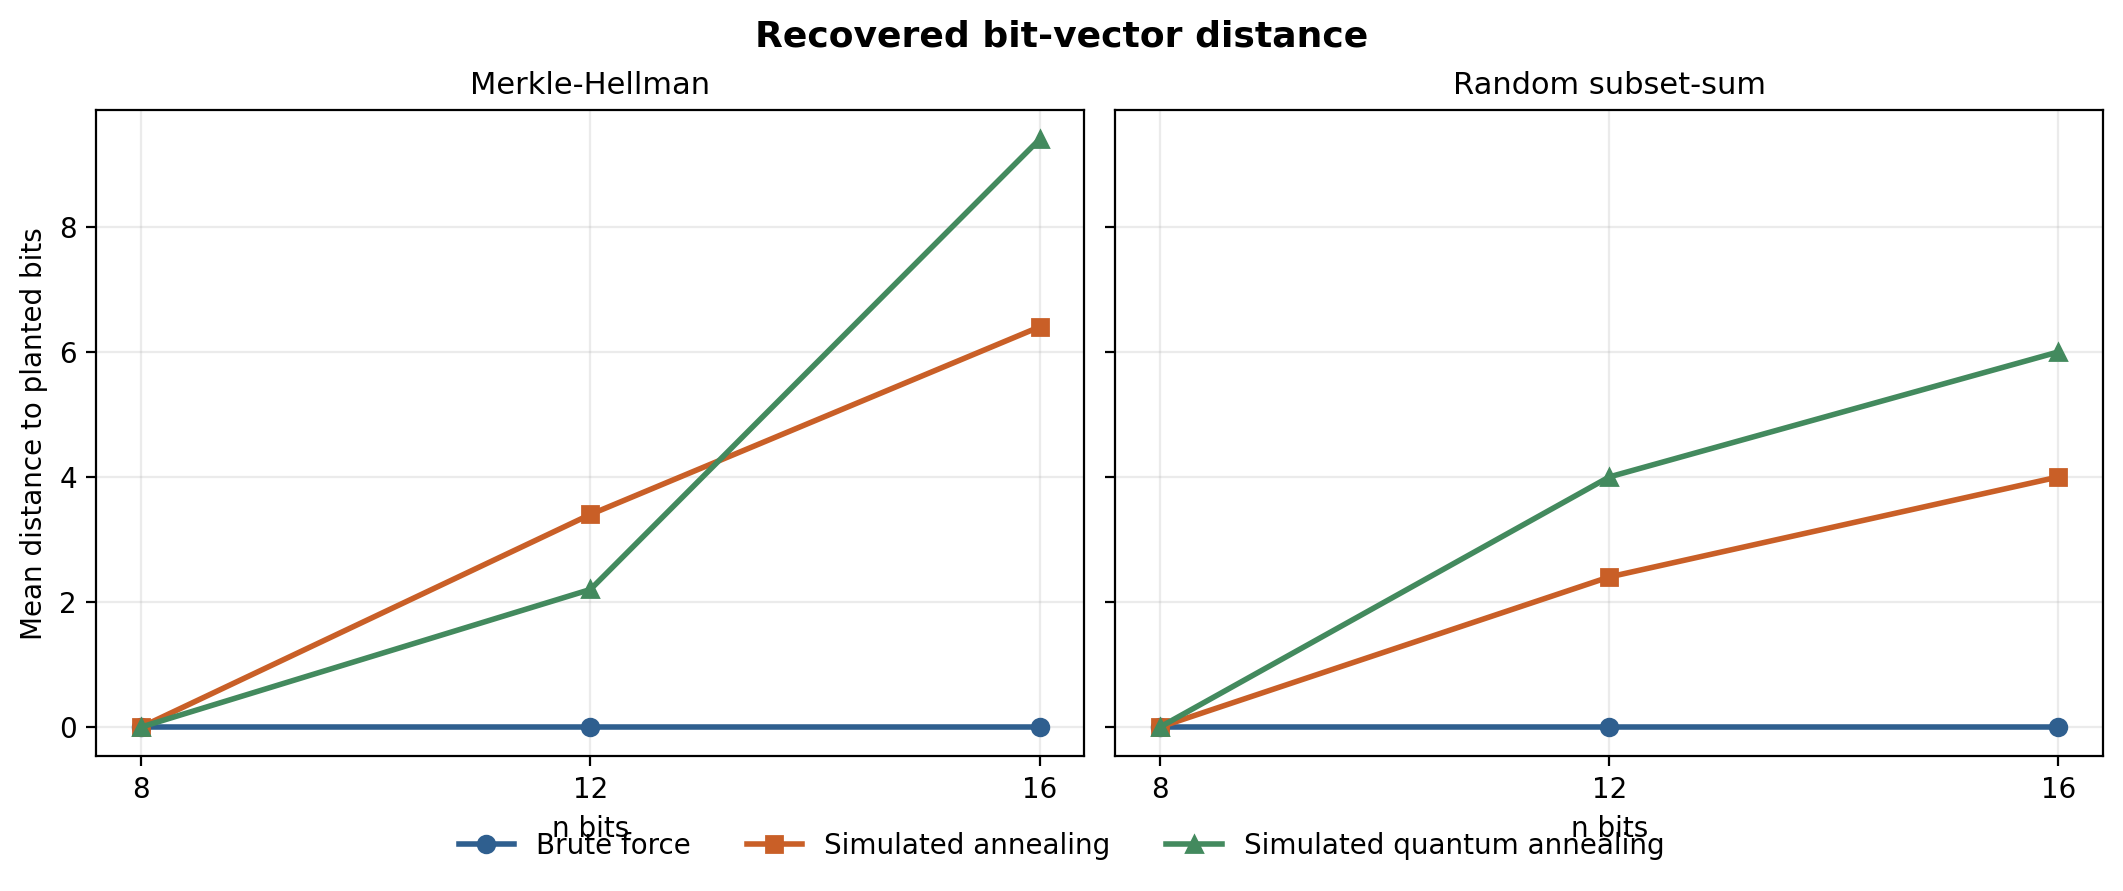

In [14]:
plot_names = [
    "success_rate_vs_n.png",
    "runtime_ms_vs_n.png",
    "objective_value_vs_n.png",
    "hamming_distance_vs_n.png",
]

for plot_name in plot_names:
    plot_path = plots_dir / plot_name
    if plot_path.exists():
        display(Image(filename=str(plot_path)))
    else:
        print(f"Missing plot: {plot_path}")